In [3]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(r"C:\Users\rohit\OneDrive\Desktop\water\ip\water_potability copy.csv")

# Fill missing values based on Potability class
df.loc[df["Potability"] == 0] = df[df["Potability"] == 0].fillna(df[df["Potability"] == 0].mean())
df.loc[df["Potability"] == 1] = df[df["Potability"] == 1].fillna(df[df["Potability"] == 1].mean())

# Normalize and clip
df["ph"] = df["ph"].clip(5, 9)
df["ph_normalized"] = (df["ph"] - 5) / (9 - 5) * 0.1
df["Sulfate"] = df["Sulfate"].clip(100, 300)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Feature and target
features = ["ph_normalized", "Solids", "Chloramines", "Sulfate", "Turbidity",
            "Hardness", "Conductivity", "Organic_carbon", "Trihalomethanes"]
X = df[features]
y = df["Potability"]


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
import xgboost as xgb

model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
model_xgb.fit(X_train, y_train)


C:\Users\rohit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [09:51:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [6]:
from sklearn.metrics import accuracy_score

y_pred = model_xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Test Accuracy: {accuracy:.4f}")


XGBoost Test Accuracy: 0.7104


In [7]:
!pip install matplotlib seaborn



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\rohit\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\rohit\AppData\Local\Temp\ipykernel_11940\2179537750.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette="viridis")


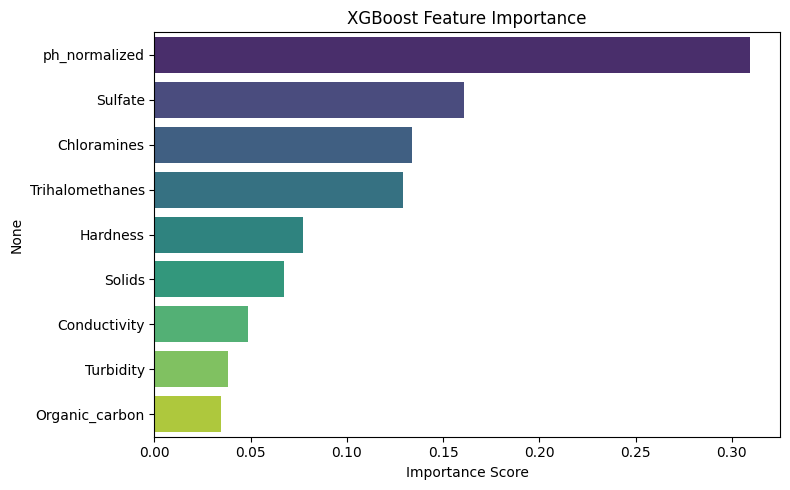

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model_xgb.feature_importances_
features = X_train.columns
feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette="viridis")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


C:\Users\rohit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Test Accuracy: 0.6372
              precision    recall  f1-score   support

           0       0.64      0.97      0.77       412
           1       0.60      0.07      0.13       244

    accuracy                           0.64       656
   macro avg       0.62      0.52      0.45       656
weighted avg       0.62      0.64      0.53       656

--------------------------------------------------
SVM Test Accuracy: 0.6280
              precision    recall  f1-score   support

           0       0.63      1.00      0.77       412
           1       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656

--------------------------------------------------
KNN Test Accuracy: 0.5305
              precision    recall  f1-score   support

           0       0.61      0.69      0.65       412
           1       0.33      0.26      0.

C:\Users\rohit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rohit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rohit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

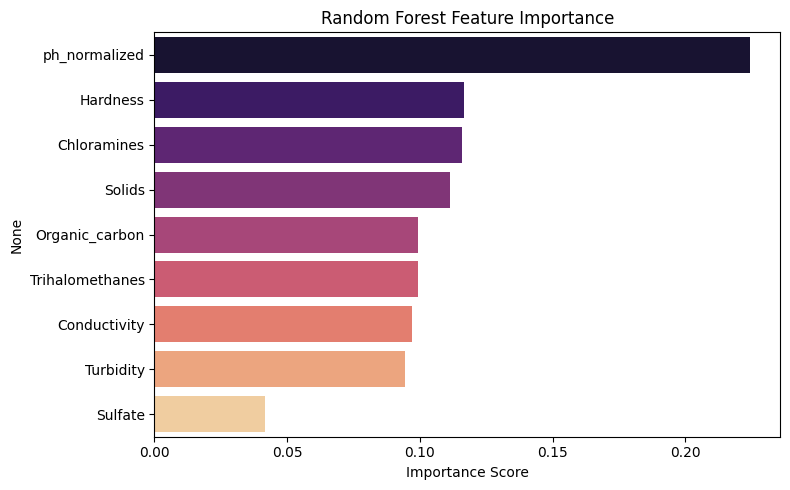

In [10]:
from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Dictionary to store models and their results
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": model_xgb  # Already trained
}

# Train, predict and evaluate each model
for name, model in models.items():
    if name != "XGBoost":  # Already trained above
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Test Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)



plt.figure(figsize=(8, 5))
sns.barplot(x=feat_importance_rf.values, y=feat_importance_rf.index, palette="magma")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
